# Capstone Project
__Name:__ Maryam Mohamed Boorlanka

__Topic Name:__ Sentiment Analysis of Amazon Food Reviews


# Introduction
In today’s fast-paced digital world, data has become a core asset for understanding customer behavior. With the large volume of online reviews generated every day, analyzing customer opinions manually is no longer practical. This project focuses on building a sentiment analysis system that classifies Amazon food reviews into positive and negative sentiments to provide meaningful insights into customer satisfaction.


## Problem Statement + Aim
With thousands of food reviews on Amazon, understanding customer sentiment at scale becomes challenging. This project aims to develop a sentiment classifier that distinguishes between positive and negative reviews, providing consistent and actionable insights into customer satisfaction.

## Objectives
The main objectives of this project are:
- To analyze customer reviews and identify patterns related to positive and negative sentiment.
- To examine how text preprocessing and feature engineering affect model performance.
- To build and compare multiple sentiment classification models and select the best-performing one.


# Data Inspection
## Data Dictionary
 In a table format mention the Columns that your data contains along with the Description


## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…


In [ ]:
# =========================
# Basic libraries
# =========================
import numpy as np
import pandas as pd
import re
import string
import math
import warnings

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# =========================
# NLP & NLTK
# =========================
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import tokenize
from nltk.probability import FreqDist

# =========================
# Transformers / Deep Learning
# =========================
import torch
from torch.nn.functional import softmax
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
    logging as hf_logging
)

# =========================
# ML tools (Scikit-learn & Imbalanced-learn)
# =========================
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    ENGLISH_STOP_WORDS
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn import metrics
from imblearn.over_sampling import RandomOverSampler

# =========================
# Progress bar
# =========================
from tqdm import tqdm, trange

# =========================
# Settings & warnings
# =========================
warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

nltk.download("stopwords")
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (17, 7)
plt.rcParams["font.size"] = 18

# =========================
# Load tokenizer
# =========================
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Load the Amazon Fine Food Reviews dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/GA /Final GA Project/Data/Reviews.csv")
print ("the data load successfully. ")

Mounted at /content/drive
the data load successfully. 


#### Initial Data Exploration

#### Display basic information about data set

In [ ]:
print("Shap of data =>", df.shape)

Shap of data => (568454, 10)


In [ ]:
print("first five columns: "),display(df.head())

first five columns: 


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


(None, None)

Check for missing values


In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


Identify the distribution of review scores (1–5)

In [ ]:
df['Score'].value_counts().sort_index()

,count
Score,
1,52268
2,29769
3,42640
4,80655
5,363122


Text Sample Inspection

In [ ]:
for i, review in enumerate(df['Text'][35:40], start=35):
    print(f"\nReview {i}:\n{review}\n")


Review 35:
McCann's Instant Irish Oatmeal, Variety Pack of Regular, Apples & Cinnamon, and Maple & Brown Sugar, 10-Count Boxes (Pack of 6)<br /><br />I'm a fan of the McCann's steel-cut oats, so I thought I'd give the instant variety a try. I found it to be a hardy meal, not too sweet, and great for folks like me (post-bariatric surgery) who need food that is palatable, easily digestible, with fiber but won't make you bloat.


Review 36:
For those of us with celiac disease this product is a lifesaver and what could be better than getting it at almost half the price of the grocery or health food store!  I love McCann's instant oatmeal - all flavors!!!<br /><br />Thanks,<br />Abby


Review 37:
What else do you need to know? Oatmeal, instant (make it with a half cup of low-fat milk and add raisins;nuke for 90 seconds). More expensive than Kroger store brand oatmeal and maybe a little tastier or better texture or something. It's still just oatmeal. Mmm, convenient!


Review 38:
I WAS VISI

# Labeling Data

This step converts numerical review scores into sentiment labels (Positive or Negative) based on the score.

In [ ]:
# Copy score clomun
df ['score2'] = df['Score']

In [ ]:
# rating 4, 5 => Positive; 1, 2, 3 => Negative

def scorings (score):
    if score > 3:
        return "Positive"
    else:
        return "Nagative"

In [ ]:
df['Score'] = df['Score'].apply(scorings)

### Quick EDA

The class distribution was visualized to see how the sentiment labels are distributed in the dataset.

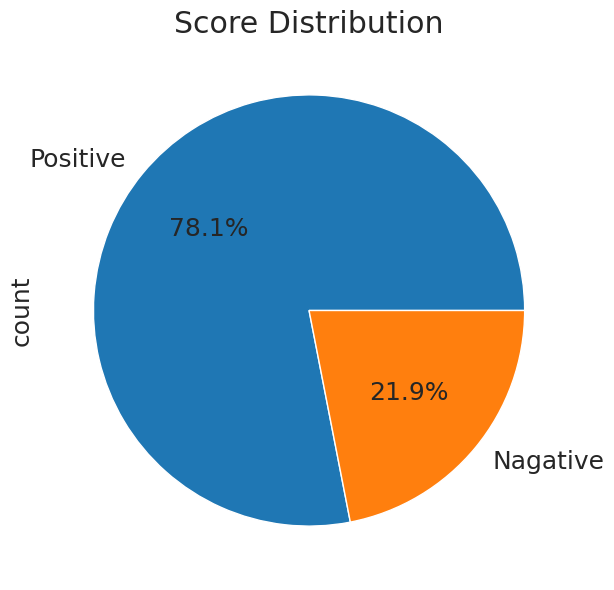

In [ ]:
df['Score'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Score Distribution')
plt.show()

Calculate imbalance ratio


In [ ]:
class_counts = df['Score'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

Imbalance Ratio: 3.56


results showed a clear class imbalance:

For every **one** negative review, there are approximately **3.5** positive reviews.

## Data Cleaning
This step cleans the text by converting it to lowercase, removing numbers, punctuation, and stopwords.

In [ ]:
def clean_text(text):
    # make sure the input is a string
    text = str(text)

    # 1 convert to lowercase
    text = text.lower()

    # 2 remove numbers (optional)
    text = re.sub(r'\d+', ' ', text)

    # 3 remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4 split text and remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]

    # 5 join cleaned text into a string
    text = " ".join(tokens)

    return text


Apply the cleaning function to the text column.


In [ ]:
df['clean_text'] = df['Text'].apply(clean_text)

Display a sample review before and after cleaning to show the effect of preprocessing.


In [ ]:
print('=== Before Cleaning ===')
print(df['Text'].iloc[7])
print('')
print('=== After Cleaning ===')
print(df['clean_text'].iloc[7])

=== Before Cleaning ===
This taffy is so good.  It is very soft and chewy.  The flavors are amazing.  I would definitely recommend you buying it.  Very satisfying!!

=== After Cleaning ===
taffy good soft chewy flavors amazing would definitely recommend buying satisfying


# Over Sampling

After cleaning the text, oversampling is applied on the training data to reduce class imbalance.


In [ ]:
# Prepare data
X = df['clean_text']
y = df['Score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Before Oversampling:")
print(y_train.value_counts())

# Calculate 30% increase for minority class
minority_count = y_train.value_counts().min()
new_count = int(minority_count * 1.30)

# Apply oversampling
minority_class = y_train.value_counts().idxmin()
ros = RandomOverSampler(
    sampling_strategy={minority_class: new_count},
    random_state=42
)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train.to_frame(), y_train
)

print("\nAfter Oversampling:")
print(y_train_resampled.value_counts())

Before Oversampling:
Score
Positive    355021
Nagative     99742
Name: count, dtype: int64

After Oversampling:
Score
Positive    355021
Nagative    129664
Name: count, dtype: int64


### Final Dataset Preparation


Relevant columns were selected after oversampling, and the cleaned dataset was saved for modeling.

In [ ]:
# Select only the important columns
important_cols = [
    "Id",
    "ProductId",
    "Score",
    "score2",
    "clean_text",
]

# Create a cleaned dataframe with only those columns
df_clean = df[important_cols].copy()

# Save to a new CSV file
df_clean.to_csv("/content/drive/MyDrive/GA /Final GA Project/Data/sentiment_clean.csv", index=False)

df_clean.head()

,Id,ProductId,Score,score2,clean_text
0,1,B001E4KFG0,Positive,5,bought several vitality canned dog food produc...
1,2,B00813GRG4,Nagative,1,product arrived labeled jumbo salted peanuts p...
2,3,B000LQOCH0,Positive,4,confection around centuries light pillowy citr...
3,4,B000UA0QIQ,Nagative,2,looking secret ingredient robitussin believe f...
4,5,B006K2ZZ7K,Positive,5,great taffy great price wide assortment yummy ...


# Exploratory Data Analysis (EDA) After Oversampling
This EDA was done after oversampling to check how the class distribution changed and became more balanced.[link text](https://)

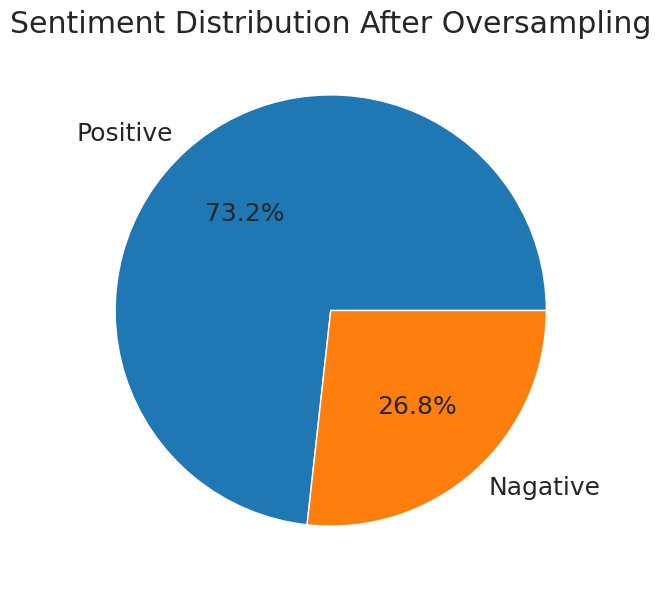

In [ ]:
y_train_resampled.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sentiment Distribution After Oversampling')
plt.ylabel('')
plt.show()

# EDA for Modeling
This EDA focuses on preparing the data for modeling by analyzing important words and improving feature extraction.

### Custom Stop Words

After running tf-idf and bag of words multiple time, extra stop words were noticed
so I created a list of custom stop words to filter out and ran both tf-idf and bag of words again with relevant words only

In [ ]:
custom_stop_words = list(ENGLISH_STOP_WORDS) + [

    # HTML / web
    'br', 'http', 'www',

    # Platform / shopping
    'amazon', 'product', 'products', 'item', 'items', 'brand', 'company',
    'buy', 'bought', 'buying', 'purchase', 'purchased', 'order', 'ordered',
    'price', 'value', 'deal', 'online', 'store',

    # Packaging / quantity
    'cup', 'cups', 'bag', 'box', 'pack', 'package', 'size',
    'piece', 'pieces', 'container', 'bottle',

    # Time / frequency
    'time', 'day', 'days', 'week', 'weeks', 'month', 'months', 'year', 'years',
    'morning', 'night',

    # Usage / actions
    'use', 'used', 'using', 'try', 'tried', 'make', 'made', 'add', 'added',
    'mix', 'mixed', 'cook', 'cooking', 'eat', 'eating', 'drink', 'drinking',

    # Logistics
    'arrived', 'received', 'came', 'left', 'wait', 'waiting', 'delivery',
    'ship', 'shipping',

    # People
    'people', 'person', 'family', 'friend', 'friends', 'husband', 'wife',
    'kid', 'kids',

    # General fillers
    'thing', 'things', 'stuff', 'kind', 'type', 'way', 'lot', 'bit',
    'actually', 'probably', 'maybe','really', 'think', 'little','know','got'
]


Most Common words (TF-IDF)

In [ ]:
#  1 Calculate TF-IDF
vectorizer = TfidfVectorizer(max_features=20, stop_words=custom_stop_words)
tfidf = vectorizer.fit_transform(df_clean["clean_text"].fillna(""))

# result
terms = vectorizer.get_feature_names_out() # يراوينا الكلمات المهمة
scores = tfidf.sum(axis=0).A1

# Show results
results = pd.DataFrame({'term': terms, 'score': scores}) # create table
results = results.sort_values('score', ascending=False) # show table in as

print(results)

         term         score
10       like  77461.048157
8        good  72487.390397
9       great  70009.092479
16      taste  58426.484851
11       love  55428.079983
5      flavor  52139.770323
3      coffee  50300.886626
6        food  40619.522208
18        tea  38816.887058
0        best  36508.628658
1      better  30695.267092
4         dog  27012.017162
2   chocolate  22381.550639
15      sweet  21760.368496
7        free  21699.390987
13  recommend  21538.401783
14      sugar  20777.721684
19      water  20304.466838
17     tastes  19925.108853
12       nice  19835.225340


Bag of words

In [ ]:
# Bag of Words

vectorizer = CountVectorizer(
    max_features=20,
    stop_words=custom_stop_words
)
bow = vectorizer.fit_transform(df_clean["clean_text"].fillna(""))

# Get results
terms = vectorizer.get_feature_names_out()
counts = bow.sum(axis=0).A1

# Show results
bow_r = pd.DataFrame({'term': terms, 'count': counts})
bow_r = bow_r.sort_values('count', ascending=False)

print(bow_r)

         term   count
10       like  256216
8        good  200644
16      taste  172856
9       great  167176
3      coffee  166786
5      flavor  148028
18        tea  138204
6        food  128525
11       love  127520
0        best   76837
1      better   70768
4         dog   69852
19      water   61619
2   chocolate   61149
14      sugar   57399
15      sweet   52708
7        free   50706
17     tastes   45623
13  recommend   42674
12       nice   41520


Word Cloud

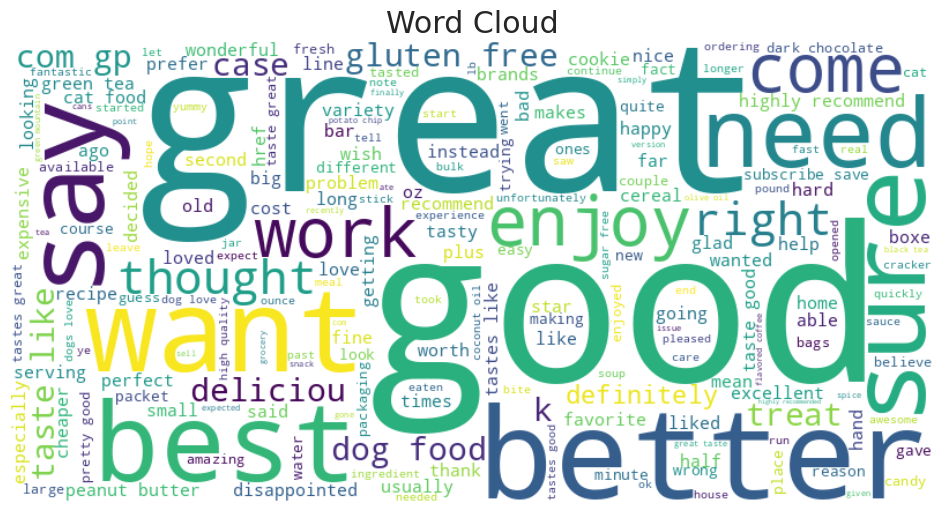

In [ ]:
# Combine all text
all_text = ' '.join(df_clean["clean_text"].fillna(''))

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stop_words
).generate(all_text)

# Show
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()

# Model Building



## Model 1: Model Name
### Modeling


In [ ]:
# initialize a sentiment analysis pipeline with your model
pipe = pipeline( "sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment", device=0, batch_size=32, truncation=True, max_length=128)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# run the pipeline on the reviews column 8
# note: our pipeline can take a list of documents, so .tolist() may be helpful
print("Running sentiment analysis...")
results = pipe(df_clean["clean_text"].iloc[:50000].tolist())

Running sentiment analysis...


In [ ]:
# Save predicted label and confidence score
df_clean.loc[:len(results)-1, ["predicted_label", "predicted_score"]] = pd.DataFrame([(r["label"], r["score"]) for r in results]).values

# Convert model labels to binary sentiment (no Neutral)
label_text_map = {
    "LABEL_0": "Negative",  # negative
    "LABEL_1": "Negative",  # treat neutral as negative
    "LABEL_2": "Positive"   # positive
}

df_clean["predicted_label"] = df_clean["predicted_label"].map(label_text_map)

df_clean.head()


,Id,ProductId,Score,score2,clean_text,predicted_label,predicted_score
0,1,B001E4KFG0,Positive,5,bought several vitality canned dog food produc...,Positive,0.903325
1,2,B00813GRG4,Nagative,1,product arrived labeled jumbo salted peanuts p...,Negative,0.826678
2,3,B000LQOCH0,Positive,4,confection around centuries light pillowy citr...,Positive,0.873940
3,4,B000UA0QIQ,Nagative,2,looking secret ingredient robitussin believe f...,Positive,0.652046
4,5,B006K2ZZ7K,Positive,5,great taffy great price wide assortment yummy ...,Positive,0.985340


### Performance


### 1) Genaral Metrics

In [ ]:
# Build y_true and y_pred
y_true = df_clean["Score"].replace("Nagative", "Negative").astype(str).str.strip()
y_pred = df_clean["predicted_label"].astype(str).str.strip()

# Keep only binary classes
valid = ["Positive", "Negative"]
mask = y_true.isin(valid) & y_pred.isin(valid)

y_true = y_true[mask]
y_pred = y_pred[mask]

print("Model 1 - General Metrics")
print("Accuracy:", metrics.accuracy_score(y_true, y_pred))
print("Precision:", metrics.precision_score(y_true, y_pred, pos_label="Positive"))
print("Recall:", metrics.recall_score(y_true, y_pred, pos_label="Positive"))
print("F1:", metrics.f1_score(y_true, y_pred, pos_label="Positive"))


Model 1 - General Metrics
Accuracy: 0.79918
Precision: 0.8859871051987268
Recall: 0.8477276276745276
F1: 0.8664352128975618


### 2) Per-class performance





In [ ]:
from sklearn.metrics import classification_report
print("Model 1 - Per-class Performance")
print(classification_report(y_true, y_pred))

Model 1 - Per-class Performance
              precision    recall  f1-score   support

    Negative       0.56      0.64      0.60     11582
    Positive       0.89      0.85      0.87     38418

    accuracy                           0.80     50000
   macro avg       0.72      0.74      0.73     50000
weighted avg       0.81      0.80      0.80     50000



## Model 2: DistilBERT base uncased finetuned SST-2

### Modeling


In [ ]:
# initialize sentiment analysis pipeline with Model 2
pipe2 = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0, batch_size=32, truncation=True, max_length=128)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
# run the pipeline on the reviews column
print("Running sentiment analysis (DistilBERT)...")
results2 = pipe2(df_clean["clean_text"].iloc[:50000].tolist())


Running sentiment analysis (DistilBERT)...


In [ ]:
# Save predicted label and confidence score (Model 2)
df_clean.loc[:len(results2)-1, ["predicted_label_m2", "predicted_score_m2"]] = (pd.DataFrame([(r["label"], r["score"]) for r in results2]).values)

# Convert model labels to binary sentiment (DistilBERT already binary)
label_text_map_m2 = { "NEGATIVE": "Negative", "POSITIVE": "Positive" }

df_clean["predicted_label_m2"] = df_clean["predicted_label_m2"].map(label_text_map_m2)

df_clean.head()

,Id,ProductId,Score,score2,clean_text,predicted_label,predicted_score,actual_label,pred_label,predicted_label_m2,predicted_score_m2
0,1,B001E4KFG0,Positive,5,bought several vitality canned dog food produc...,Positive,0.903325,Positive,Positive,Positive,0.529468
1,2,B00813GRG4,Nagative,1,product arrived labeled jumbo salted peanuts p...,Negative,0.826678,Negative,Negative,Negative,0.997915
2,3,B000LQOCH0,Positive,4,confection around centuries light pillowy citr...,Positive,0.873940,Positive,Positive,Positive,0.999459
3,4,B000UA0QIQ,Nagative,2,looking secret ingredient robitussin believe f...,Positive,0.652046,Negative,Positive,Positive,0.809940
4,5,B006K2ZZ7K,Positive,5,great taffy great price wide assortment yummy ...,Positive,0.985340,Positive,Positive,Positive,0.998064


### Performance


### 1) Genaral Metrics

In [ ]:
# Build y_true and y_pred for Model 2
y_true_m2 = df_clean["Score"].replace("Nagative", "Negative").astype(str).str.strip()
y_pred_m2 = df_clean["predicted_label_m2"].astype(str).str.strip()

# Keep only binary classes
valid = ["Positive", "Negative"]
mask = y_true_m2.isin(valid) & y_pred_m2.isin(valid)

y_true_m2 = y_true_m2[mask]
y_pred_m2 = y_pred_m2[mask]

print("Model 2 - General Metrics")
print("Accuracy:", metrics.accuracy_score(y_true_m2, y_pred_m2))
print("Precision:", metrics.precision_score(y_true_m2, y_pred_m2, pos_label="Positive"))
print("Recall:", metrics.recall_score(y_true_m2, y_pred_m2, pos_label="Positive"))
print("F1:", metrics.f1_score(y_true_m2, y_pred_m2, pos_label="Positive"))


Model 2 - General Metrics
Accuracy: 0.65566
Precision: 0.9193069894387089
Recall: 0.6049508043104794
F1: 0.7297131823105544


### 2) Per-class performance





In [ ]:
print("Model 2 - Per-class Performance")
print(classification_report(y_true_m2, y_pred_m2))

Model 2 - Per-class Performance
              precision    recall  f1-score   support

    Negative       0.39      0.82      0.53     11582
    Positive       0.92      0.60      0.73     38418

    accuracy                           0.66     50000
   macro avg       0.65      0.71      0.63     50000
weighted avg       0.80      0.66      0.68     50000



## Model 3: SiEBERT - English-Language Sentiment Classification
### Modeling



In [ ]:
# initialize sentiment analysis pipeline with Model 3
pipe3 = pipeline("sentiment-analysis", model="siebert/sentiment-roberta-large-english", device=0, batch_size=32, truncation=True, max_length=128)


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# run the pipeline on the reviews column
print("Running sentiment analysis (RoBERTa Large)...")
results3 = pipe3(df_clean["clean_text"].iloc[:50000].tolist())

Running sentiment analysis (RoBERTa Large)...


In [ ]:
# Save predicted label and confidence score (Model 3)
df_clean.loc[:len(results3)-1, ["predicted_label_m3", "predicted_score_m3"]] = (pd.DataFrame([(r["label"], r["score"]) for r in results3]).values)

# Convert model labels to binary sentiment (already binary)
label_text_map_m3 = {"NEGATIVE": "Negative","POSITIVE": "Positive"}

df_clean["predicted_label_m3"] = df_clean["predicted_label_m3"].map(label_text_map_m3)

df_clean.head()

,Id,ProductId,Score,score2,clean_text,predicted_label,predicted_score,actual_label,pred_label,predicted_label_m2,predicted_score_m2,predicted_label_m3,predicted_score_m3
0,1,B001E4KFG0,Positive,5,bought several vitality canned dog food produc...,Positive,0.903325,Positive,Positive,Positive,0.529468,Positive,0.998842
1,2,B00813GRG4,Nagative,1,product arrived labeled jumbo salted peanuts p...,Negative,0.826678,Negative,Negative,Negative,0.997915,Negative,0.998474
2,3,B000LQOCH0,Positive,4,confection around centuries light pillowy citr...,Positive,0.873940,Positive,Positive,Positive,0.999459,Positive,0.998904
3,4,B000UA0QIQ,Nagative,2,looking secret ingredient robitussin believe f...,Positive,0.652046,Negative,Positive,Positive,0.809940,Positive,0.998372
4,5,B006K2ZZ7K,Positive,5,great taffy great price wide assortment yummy ...,Positive,0.985340,Positive,Positive,Positive,0.998064,Positive,0.998901


### Performance


### 1) Genaral Metrics

In [ ]:
# Build y_true and y_pred for Model 3
y_true_m3 = df_clean["Score"].replace("Nagative", "Negative").astype(str).str.strip()
y_pred_m3 = df_clean["predicted_label_m3"].astype(str).str.strip()

# Keep only binary classes
valid = ["Positive", "Negative"]
mask = y_true_m3.isin(valid) & y_pred_m3.isin(valid)

y_true_m3 = y_true_m3[mask]
y_pred_m3 = y_pred_m3[mask]

print("Model 3 - General Metrics")
print("Accuracy:", metrics.accuracy_score(y_true_m3, y_pred_m3))
print("Precision:", metrics.precision_score(y_true_m3, y_pred_m3, pos_label="Positive"))
print("Recall:", metrics.recall_score(y_true_m3, y_pred_m3, pos_label="Positive"))
print("F1:", metrics.f1_score(y_true_m3, y_pred_m3, pos_label="Positive"))


Model 3 - General Metrics
Accuracy: 0.85074
Precision: 0.9049687328292211
Recall: 0.9002811182258317
F1: 0.9026188394639665


### 2) Per-class performance

In [ ]:
print("Model 3 - Per-class Performance")
print(classification_report(y_true_m3, y_pred_m3))

Model 3 - Per-class Performance
              precision    recall  f1-score   support

    Negative       0.67      0.69      0.68     11582
    Positive       0.90      0.90      0.90     38418

    accuracy                           0.85     50000
   macro avg       0.79      0.79      0.79     50000
weighted avg       0.85      0.85      0.85     50000



# Conclusion

## Model Comparison
![alt here](https://drive.google.com/uc?export=view&id=1ufU3IgDJBSi_dMM6_zJNrljWDeFLmeJu)

## - State which model is the best? **Model 3**
## - Why is that model the best? because it provided the most balanced and consistent performance across all evaluation metrics. It achieved an **accuracy** of 85% and an **F1**-**score** of 0.90, showing strong ability to correctly classify both positive and negative reviews. Therefore, this model was chosen for the final sentiment classification task.


## Discussion
- Business implications
1. The model helps understand customer sentiment and overall satisfaction.

2. The results can support business decisions to improve products and services.
- Limitations and future improvements
1. The model was evaluated on a subset of the dataset due to computational limitations.

2. Future work could use more data or fine-tune the model to improve performance.


# References & Appendix
### Models Used in This Project

The following three pre-trained transformer models were used and compared in this project:

- **Model 1: Twitter RoBERTa (cardiffnlp/twitter-roberta-base-sentiment)**  
  Hugging Face Model Card:  
  https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment  

  Barbieri, F., Camacho-Collados, J., Espinosa Anke, L., & Neves, L. (2020).  
  *TweetEval: Unified Benchmark and Comparative Evaluation for Tweet Classification.*  
  EMNLP 2020 Findings.

- **Model 2: DistilBERT (Fine-tuned on SST-2)**  
  Hugging Face Model Card:  
  https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english

- **Model 3: SiEBERT (RoBERTa Large – English Sentiment Classification)**  
  Related resources include pysentimiento, RoBERTuito, and TASS.

---

### Additional References

- **Analytics Vidhya (2020).** Beginner’s Guide to Exploratory Data Analysis on Text Data.  
  https://www.analyticsvidhya.com/blog/2020/04/beginners-guide-exploratory-data-analysis-text-data/

- **Muza, R. (2023).** Building a Sentiment Analysis Model Using Transformers: A Step-by-Step Guide. Medium.  
  https://medium.com/@rafiatriamuza/building-a-sentiment-analysis-model-using-transformers-a-step-by-step-guide-fee0e7c7d8fc

- **Analytics Vidhya (2021).** All NLP Tasks Using the Transformers Package.  
  https://www.analyticsvidhya.com/blog/2021/12/all-nlp-tasks-using-transformers-package/

- **Singh, H. (2022).** Complete Guide to EDA on Text Data. Kaggle.  
  https://www.kaggle.com/code/harshsingh2209/complete-guide-to-eda-on-text-data#Setup
